In [1]:
import sqlite3

In [2]:
import pandas as pd

In [3]:
import seaborn as sns

In [4]:
import matplotlib.pyplot as plt

In [5]:
conn = sqlite3.connect(r"C:\Users\Rishikesh\Downloads\inventory.db")

In [7]:
tables = pd.read_sql_query("select name from sqlite_master where type = 'table'",conn)
for table in tables['name']:
    print('Table name',table)
    df = pd.read_sql_query(f"select * from {table} limit 5",conn)
    display(df)

Table name purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table name purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table name vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table name begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table name end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [8]:
purchase_agg_df = pd.read_sql_query("""
select
p.PONumber,
count(distinct p.Brand) as total_brands,
sum(p.Quantity) as total_item_quantity,
sum(p.Dollars) as total_item_dollars,
avg(julianday(p.ReceivingDate) - julianday(p.PODate)) as avg_receiving_delay
from purchases p
group by p.PONumber
""", conn)

In [9]:
purchase_agg_df.shape

(5543, 5)

In [10]:
pd.read_sql_query("""
select
vi.PONumber,
vi.Quantity as invoice_quantity,
vi.Dollars as invoice_dollars,
vi.Freight,
(julianday(vi.InvoiceDate) - julianday(vi.PODate)) AS days_po_to_invoice,
(julianday(vi.PayDate) - julianday(vi.InvoiceDate)) AS days_to_pay
from vendor_invoice vi
""", conn)

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay
0,8124,6,214.26,3.47,14.0,43.0
1,8137,15,140.55,8.57,16.0,45.0
2,8169,5,106.60,4.61,16.0,38.0
3,8106,10100,137483.78,2935.20,23.0,24.0
4,8170,1935,15527.25,429.20,14.0,36.0
...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0
5539,13661,4617,37300.48,186.50,18.0,39.0
5540,13643,9848,202815.78,932.95,11.0,33.0
5541,13602,24747,149007.56,819.54,14.0,36.0


In [23]:
df = pd.read_sql_query("""
WITH purchase_agg AS (
    SELECT
        p.PONumber,
        COUNT(DISTINCT p.Brand) AS total_brands,
        SUM(p.Quantity) AS total_item_quantity,
        SUM(p.Dollars) AS total_item_dollars,
        AVG(julianday(p.ReceivingDate) - julianday(p.PODate)) AS avg_receiving_delay
    FROM purchases p
    GROUP BY p.PONumber
)
SELECT
    vi.PONumber,
    vi.Quantity AS invoice_quantity,
    vi.Dollars AS invoice_dollars,
    vi.Freight,
    (julianday(vi.InvoiceDate) - julianday(vi.PODate)) AS days_po_to_invoice,
    (julianday(vi.PayDate) - julianday(vi.InvoiceDate)) AS days_to_pay,
    pa.total_brands,
    pa.total_item_quantity,
    pa.total_item_dollars,
    pa.avg_receiving_delay
FROM vendor_invoice vi
LEFT JOIN purchase_agg pa
ON vi.PONumber = pa.PONumber
""", conn)

,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [14]:
df.isnull().sum()

InventoryId    0
Store          0
City           0
Brand          0
Description    0
Size           0
onHand         0
Price          0
endDate        0
dtype: int64

In [15]:
df.dtypes

InventoryId     object
Store            int64
City            object
Brand            int64
Description     object
Size            object
onHand           int64
Price          float64
endDate         object
dtype: object

In [24]:
print(df.columns.tolist())

['PONumber', 'invoice_quantity', 'invoice_dollars', 'Freight', 'days_po_to_invoice', 'days_to_pay', 'total_brands', 'total_item_quantity', 'total_item_dollars', 'avg_receiving_delay']


In [25]:
df["flag_invoice"] = df.apply(create_invoice_risk_label, axis=1)
df["flag_invoice"].value_counts()

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

In [26]:
def create_invoice_risk_label(row):

    # Invoice total mismatch with item-level total
    if (abs(row["invoice_dollars"] - row["total_item_dollars"]) > 5):
        return 1

    # Abnormally high receiving delay
    if row["avg_receiving_delay"] > 10:
        return 1

    return 0


df["flag_invoice"] = df.apply(create_invoice_risk_label, axis=1)
df["flag_invoice"].value_counts()


flag_invoice
0    3693
1    1850
Name: count, dtype: int64

<Axes: xlabel='flag_invoice'>

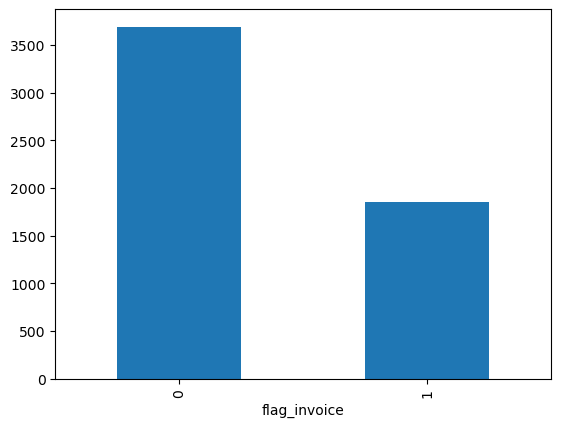

In [27]:
df['flag_invoice'].value_counts().plot(kind='bar')

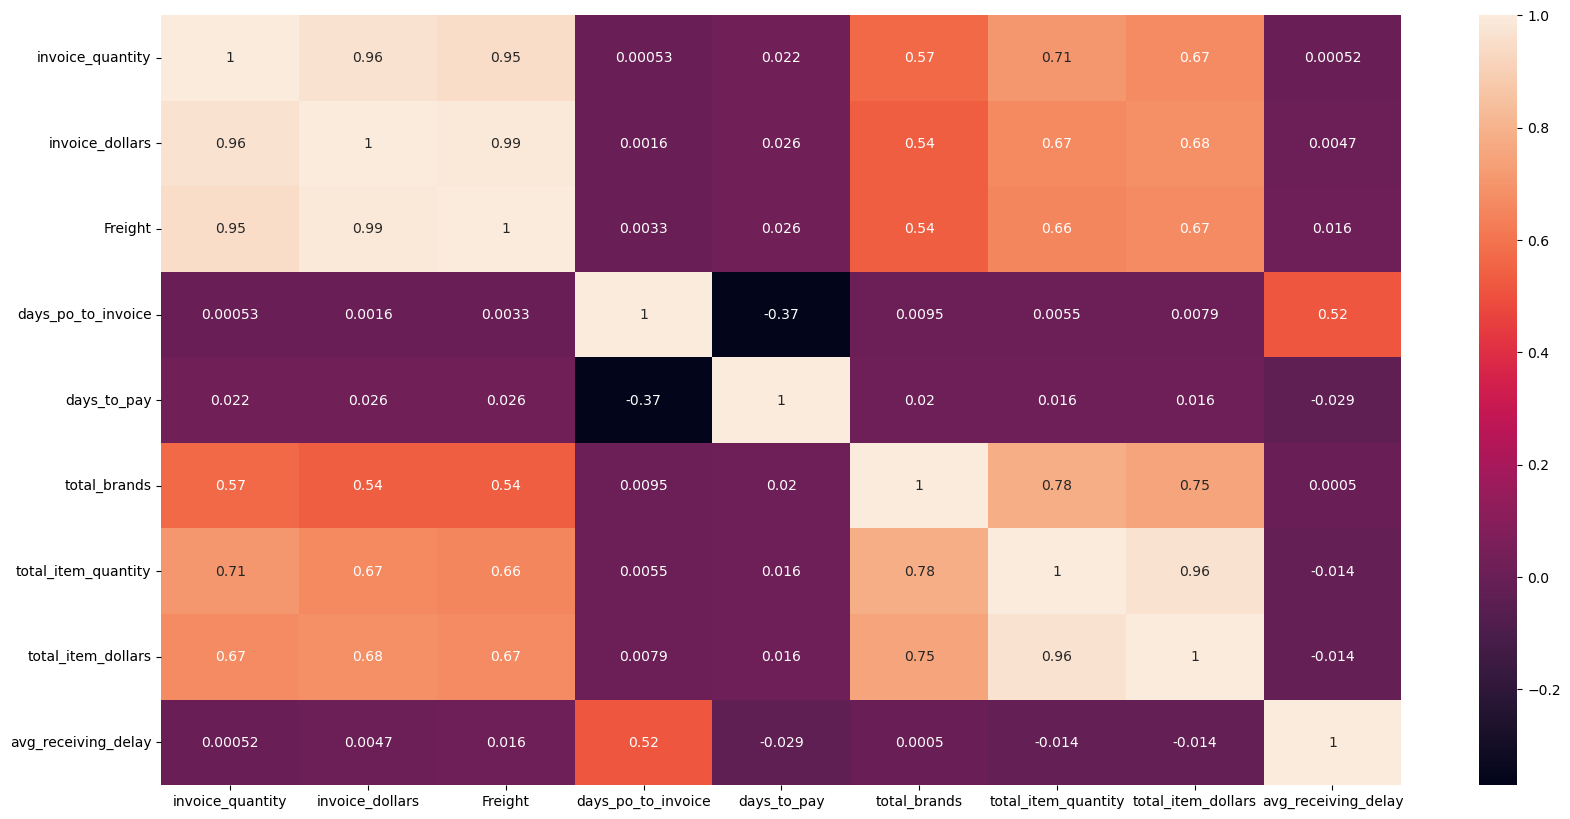

In [28]:
plt.figure(figsize=(20,10))
sns.heatmap(df.iloc[:,1:-1].corr(), annot=True)
plt.show()

In [29]:
flagged = df[df['flag_invoice'] == 1]
normal = df[df['flag_invoice'] == 0]

In [30]:
significant_features = []
non_significant_features = []
results = []

In [31]:
metrics = ['invoice_quantity', 'invoice_dollars', 'Freight',
           'days_po_to_invoice', 'days_to_pay', 'total_brands',
           'total_item_quantity', 'total_item_dollars',
           'avg_receiving_delay']

In [32]:
from scipy.stats import ttest_ind

for metric in metrics:

    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()

    t_stat, p_value = ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var=False
    )

    if p_value < 0.05:
        significant_features.append(metric)

        results.append({
            "metric": metric,
            "flagged_mean": flagged_mean.round(2),
            "normal_mean": normal_mean.round(2),
            "p_value": p_value.round(3)
        })

    else:
        non_significant_features.append(metric)

In [33]:
non_significant_features

['days_to_pay', 'total_brands']

In [34]:
significant_features

['invoice_quantity',
 'invoice_dollars',
 'Freight',
 'days_po_to_invoice',
 'total_item_quantity',
 'total_item_dollars',
 'avg_receiving_delay']

In [35]:
results

[{'metric': 'invoice_quantity',
  'flagged_mean': np.float64(6728.28),
  'normal_mean': np.float64(5723.55),
  'p_value': np.float64(0.021)},
 {'metric': 'invoice_dollars',
  'flagged_mean': np.float64(65600.61),
  'normal_mean': np.float64(54302.64),
  'p_value': np.float64(0.008)},
 {'metric': 'Freight',
  'flagged_mean': np.float64(334.02),
  'normal_mean': np.float64(276.89),
  'p_value': np.float64(0.008)},
 {'metric': 'days_po_to_invoice',
  'flagged_mean': np.float64(17.23),
  'normal_mean': np.float64(16.02),
  'p_value': np.float64(0.0)},
 {'metric': 'total_item_quantity',
  'flagged_mean': np.float64(6728.28),
  'normal_mean': np.float64(5723.55),
  'p_value': np.float64(0.021)},
 {'metric': 'total_item_dollars',
  'flagged_mean': np.float64(65600.61),
  'normal_mean': np.float64(54302.64),
  'p_value': np.float64(0.008)},
 {'metric': 'avg_receiving_delay',
  'flagged_mean': np.float64(8.47),
  'normal_mean': np.float64(7.27),
  'p_value': np.float64(0.0)}]

In [36]:
X = df[['invoice_quantity', 'invoice_dollars', 'Freight',
        'total_brands', 'total_item_quantity',
        'days_po_to_invoice', 'total_item_dollars']]

y = df['flag_invoice']

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model1 = LogisticRegression(random_state=42)
model1.fit(X_train_scaled, y_train)

model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train_scaled, y_train)

model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [40]:
evaluate_model(model1, X_test_scaled, y_test, 'Logistic Regression')
evaluate_model(model2, X_test_scaled, y_test, 'Decision Tree Classifier')
evaluate_model(model3, X_test_scaled, y_test, 'Random Forest Classifier')


Logistic Regression
Accuracy:
0.6591523895401262

Confusion Matrix:
[[709  16]
 [362  22]]

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.98      0.79       725
           1       0.58      0.06      0.10       384

    accuracy                           0.66      1109
   macro avg       0.62      0.52      0.45      1109
weighted avg       0.63      0.66      0.55      1109


Decision Tree Classifier
Accuracy:
0.8142470694319206

Confusion Matrix:
[[630  95]
 [111 273]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       725
           1       0.74      0.71      0.73       384

    accuracy                           0.81      1109
   macro avg       0.80      0.79      0.79      1109
weighted avg       0.81      0.81      0.81      1109


Random Forest Classifier
Accuracy:
0.8746618575293057

Confusion Matrix:
[[708  17]
 [122 262]]

Classificat

In [44]:
model3.feature_importances_

array([0.15137936, 0.15124851, 0.14480642, 0.07920458, 0.17669413,
       0.07717963, 0.21948736])

In [39]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model3.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance

,feature,importance
4,total_item_dollars,0.281227
3,total_item_quantity,0.194545
1,invoice_dollars,0.184961
2,Freight,0.170783
0,invoice_quantity,0.168485


In [40]:
X = df[['invoice_quantity', 'invoice_dollars', 'Freight',
        'total_item_quantity', 'total_item_dollars']]

y = df['flag_invoice']

In [42]:
from sklearn.metrics import accuracy_score, classification_report

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    print("\n", model_name)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model3 = RandomForestClassifier(random_state=42)

model3.fit(X_train_scaled, y_train)

evaluate_model(model3, X_test_scaled, y_test, 'Random Forest Classifier')


 Random Forest Classifier
Accuracy: 0.8845807033363391
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       725
           1       0.94      0.72      0.81       384

    accuracy                           0.88      1109
   macro avg       0.90      0.84      0.86      1109
weighted avg       0.89      0.88      0.88      1109



In [44]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 4, 5, 6],
    "min_samples_split": [2, 3, 5],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ['gini', 'entropy']
}

In [45]:
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

scorer = make_scorer(f1_score)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

evaluate_model(
    grid_search,
    X_test_scaled,
    y_test,
    'Random Forest Classifier'
)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

 Random Forest Classifier
Accuracy: 0.8881875563570785
              precision    recall  f1-score   support

           0       0.86      0.98      0.92       725
           1       0.96      0.71      0.81       384

    accuracy                           0.89      1109
   macro avg       0.91      0.85      0.87      1109
weighted avg       0.90      0.89      0.88      1109



In [46]:
from sklearn.metrics import confusion_matrix

In [47]:
confusion_matrix(
    grid_search.predict(X_test_scaled),
    y_test
)

array([[713, 112],
       [ 12, 272]])

In [48]:
confusion_matrix(
    model3.predict(X_test_scaled),
    y_test
)

array([[706, 109],
       [ 19, 275]])

In [49]:
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 100}